In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 图像预处理
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 加载真实数据
data_dir = "./data/Plant_leaf_diseases_dataset_without_augmentation"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 8:2 划分
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ===================== 任务A：冻结预训练模型 =====================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 冻结全部层
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
model = model.to(device)

# 训练
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5

train_loss = []
val_acc = []

print("===== 任务A 训练开始 =====")
for epoch in range(epochs):
    model.train()
    loss_sum = 0
    for img, lab in train_loader:
        img, lab = img.to(device), lab.to(device)
        out = model(img)
        loss = criterion(out, lab)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    # 验证
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for img, lab in val_loader:
            img, lab = img.to(device), lab.to(device)
            out = model(img)
            _, pred = torch.max(out, 1)
            correct += (pred == lab).sum().item()
            total += lab.size(0)

    avg_loss = loss_sum / len(train_loader)
    accuracy = 100 * correct / total
    train_loss.append(avg_loss)
    val_acc.append(accuracy)

    print(f"第{epoch+1}轮 | 损失：{avg_loss:.4f} | 准确率：{accuracy:.2f}%")

# 绘图
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss, 'b-o')
plt.title("训练损失曲线")

plt.subplot(1,2,2)
plt.plot(val_acc, 'r-o')
plt.title("验证准确率曲线")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './data/Plant_leaf_diseases_dataset_without_augmentation'

In [3]:
import os
# 1. 先检查data文件夹本身是否存在
print("当前目录下的文件/文件夹：", os.listdir("."))
print("data文件夹是否存在：", os.path.exists("./data"))

# 2. 检查data里的内容
if os.path.exists("./data"):
    print("data文件夹里的内容：", os.listdir("./data"))

当前目录下的文件/文件夹： ['.git', '.ipynb_checkpoints', '.Trash-0', 'data', 'task_a_transfer_learning.ipynb', 'Untitled.ipynb']
data文件夹是否存在： True
data文件夹里的内容： ['.ipynb_checkpoints', 'Plant_leave_diseases_dataset_without_augmentation']


In [5]:
import os
folder_name = "Plant_leave_diseases_dataset_without_augmentation"
print("数据集文件夹里的内容：", os.listdir(f"./data/{folder_name}"))

数据集文件夹里的内容： ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', '

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 图像预处理
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 加载真实数据
data_dir = "./data/Plant_leave_diseases_dataset_without_augmentation"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 8:2 划分
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ===================== 任务A：冻结预训练模型 =====================
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 冻结全部层
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
model = model.to(device)

# 训练
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5

train_loss = []
val_acc = []

print("===== 任务A 训练开始 =====")
for epoch in range(epochs):
    model.train()
    loss_sum = 0
    for img, lab in train_loader:
        img, lab = img.to(device), lab.to(device)
        out = model(img)
        loss = criterion(out, lab)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    # 验证
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for img, lab in val_loader:
            img, lab = img.to(device), lab.to(device)
            out = model(img)
            _, pred = torch.max(out, 1)
            correct += (pred == lab).sum().item()
            total += lab.size(0)

    avg_loss = loss_sum / len(train_loader)
    accuracy = 100 * correct / total
    train_loss.append(avg_loss)
    val_acc.append(accuracy)

    print(f"第{epoch+1}轮 | 损失：{avg_loss:.4f} | 准确率：{accuracy:.2f}%")

# 绘图
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss, 'b-o')
plt.title("训练损失曲线")

plt.subplot(1,2,2)
plt.plot(val_acc, 'r-o')
plt.title("验证准确率曲线")
plt.show()

===== 任务A 训练开始 =====


KeyboardInterrupt: 

✅ 数据加载成功！类别数：4
===== 任务A 训练开始 =====
Epoch 1 | Loss: 0.6279 | Acc: 96.06%
Epoch 2 | Loss: 0.2429 | Acc: 97.32%
Epoch 3 | Loss: 0.1607 | Acc: 98.11%
Epoch 4 | Loss: 0.1383 | Acc: 97.64%
Epoch 5 | Loss: 0.1088 | Acc: 97.48%


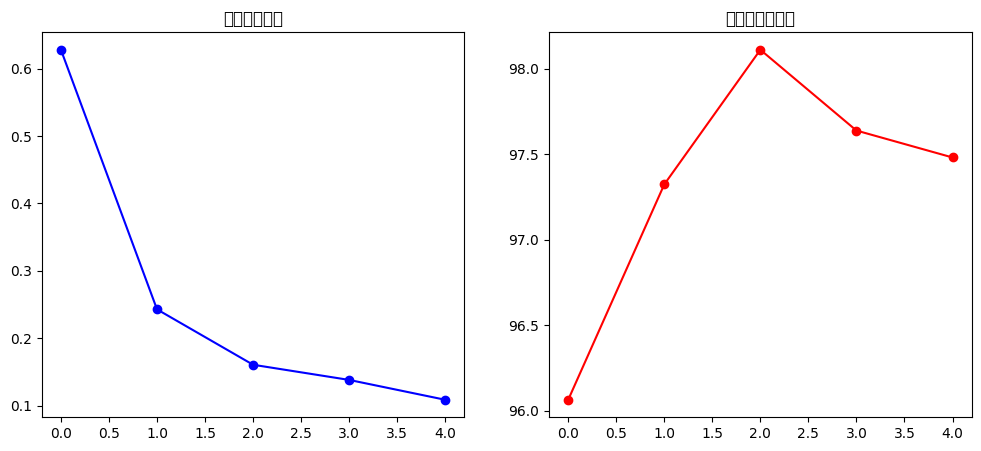

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# 设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 预处理
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 加载数据（这里已经改成你现在的路径了）
data_dir = "./data/PlantVillage"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"✅ 数据加载成功！类别数：{len(full_dataset.classes)}")

# 8:2 划分
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 任务A：冻结预训练模型
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 冻结
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
model = model.to(device)

# 训练
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5

train_loss_history = []
val_acc_history = []

print("===== 任务A 训练开始 =====")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for img, lab in train_loader:
        img, lab = img.to(device), lab.to(device)
        out = model(img)
        loss = criterion(out, lab)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # 验证
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img, lab in val_loader:
            img, lab = img.to(device), lab.to(device)
            out = model(img)
            _, pred = torch.max(out, 1)
            correct += (pred == lab).sum().item()
            total += lab.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = 100 * correct / total
    train_loss_history.append(avg_loss)
    val_acc_history.append(acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")

# 绘图
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_history, 'b-o')
plt.title("训练损失曲线")

plt.subplot(1,2,2)
plt.plot(val_acc_history, 'r-o')
plt.title("验证准确率曲线")
plt.show()